In [1]:
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from simulation import population_dataset_1, ModelWrapperPopulation 

np.random.seed(42)

In [2]:
# Theoretical values for comparison
theoretical_NDE = 1.0  # E[Y|T=1,M=m',C=0.2] - E[Y|T=0,M=m',C=0.2] = 1
theoretical_ATE = 0.55  # E[Y|T=1] - E[Y|T=0] = 1 - 0.8 * 0.5**2 - 0.5 * 1 * 0.5 - 0
theoretical_NIE = -0.45  # E[Y|T=1,M=m] - E[Y|T=1,M=m'] = 1 - 0.8 * 0.5**2 - 0.5 * 1 * 0.5 - (1)

treatment_col_index = 0
confounder_col_index = 1
mediator1_col_index = 2

def filter_close(X, col_idx, val, tol=0.1):
    return np.abs(X[:, col_idx] - val) < tol


In [71]:
def compute_nde_nie_mlp_models(X_data, y_data, treatment_col_index=0, mediator_col_index=2, confounder_col_index=1):
    """
    Compute Natural Direct Effect (NDE) and Natural Indirect Effect (NIE) using MLP models.
    
    Args:
        X_data: Feature matrix with columns [treatment, confounder, mediator]
        y_data: Outcome vector
        treatment_col_index: Index of treatment column (default: 0)
        mediator_col_index: Index of mediator column (default: 2)
        confounder_col_index: Index of confounder column (default: 1)
    
    Returns:
        Dictionary with NDE, NIE, and other estimates
    """
    from sklearn.neural_network import MLPRegressor
    # Extract variables
    T = X_data[:, treatment_col_index]  # treatment
    M = X_data[:, mediator_col_index]   # mediator
    C = X_data[:, confounder_col_index] # confounder
    Y = y_data                          # outcome
    
    print(f"Data shapes: T={T.shape}, M={M.shape}, C={C.shape}, Y={Y.shape}")
    print(f"Treatment values: {np.unique(T)}")
    print(f"Mediator range: [{np.min(M):.3f}, {np.max(M):.3f}]")
    print(f"Confounder range: [{np.min(C):.3f}, {np.max(C):.3f}]")
    
    # Step 1: Model mediator M ~ T + C (including confounder)
    X_mediator = np.column_stack((T, C))
    model_M = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    model_M.fit(X_mediator, M)
    
    # Predict mediator for T=0 and T=1 (keeping confounder as observed)
    M_pred_T0 = model_M.predict(np.column_stack((np.zeros_like(T), C)))
    M_pred_T1 = model_M.predict(np.column_stack((np.ones_like(T), C)))
    
    # Step 2: Model outcome Y ~ T + M + C
    X_outcome = np.column_stack((T, M, C))
    model_Y = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    model_Y.fit(X_outcome, Y)
    
    # Natural Direct Effect (NDE): E[Y|T=1, M(T=0), C] - E[Y|T=0, M(T=0), C]
    # Set T=1, M=M(T=0), C=observed
    X_nde_1 = np.column_stack((np.ones_like(T), M_pred_T0, C))
    Y_pred_nde_1 = model_Y.predict(X_nde_1)
    
    # Set T=0, M=M(T=0), C=observed
    X_nde_0 = np.column_stack((np.zeros_like(T), M_pred_T0, C))
    Y_pred_nde_0 = model_Y.predict(X_nde_0)
    
    NDE = np.mean(Y_pred_nde_1 - Y_pred_nde_0)
    
    # Natural Indirect Effect (NIE): E[Y|T=1, M(T=1), C] - E[Y|T=1, M(T=0), C]
    # Set T=1, M=M(T=1), C=observed
    X_nie_1 = np.column_stack((np.ones_like(T), M_pred_T1, C))
    Y_pred_nie_1 = model_Y.predict(X_nie_1)
    
    # Set T=1, M=M(T=0), C=observed
    X_nie_0 = np.column_stack((np.ones_like(T), M_pred_T0, C))
    Y_pred_nie_0 = model_Y.predict(X_nie_0)
    
    NIE = np.mean(Y_pred_nie_1 - Y_pred_nie_0)
    
    # Total Effect: NDE + NIE
    total_effect = NDE + NIE
    
    # Alternative: Direct calculation of total effect
    # E[Y|T=1, M(T=1), C] - E[Y|T=0, M(T=0), C]
    Y_pred_total_1 = model_Y.predict(np.column_stack((np.ones_like(T), M_pred_T1, C)))
    Y_pred_total_0 = model_Y.predict(np.column_stack((np.zeros_like(T), M_pred_T0, C)))
    total_effect_direct = np.mean(Y_pred_total_1 - Y_pred_total_0)
    
    print(f"\nResults:")
    print(f"Natural Direct Effect (NDE): {NDE:.4f}")
    print(f"Natural Indirect Effect (NIE): {NIE:.4f}")
    print(f"Total Effect (NDE + NIE): {total_effect:.4f}")
    print(f"Total Effect (direct calc): {total_effect_direct:.4f}")
    print(f"Difference: {abs(total_effect - total_effect_direct):.6f}")
    
    return {
        'NDE': NDE,
        'NIE': NIE,
        'total_effect': total_effect,
        'total_effect_direct': total_effect_direct,
        'model_M': model_M,
        'model_Y': model_Y,
        'M_pred_T0': M_pred_T0,
        'M_pred_T1': M_pred_T1,
        'Y_pred_nde_1': Y_pred_nde_1,
        'Y_pred_nde_0': Y_pred_nde_0,
        'Y_pred_nie_1': Y_pred_nie_1,
        'Y_pred_nie_0': Y_pred_nie_0
    }


In [72]:
# Test the NDE/NIE computation with your dataset
print("Testing NDE/NIE computation with MLP models...")

# Generate data
X_test, y_test = population_dataset_1(num_samples=10000)

# Compute NDE and NIE using MLP models
results = compute_nde_nie_mlp_models(
    X_data=X_test, 
    y_data=y_test,
    treatment_col_index=treatment_col_index,
    mediator_col_index=mediator1_col_index,
    confounder_col_index=confounder_col_index
)

# Compare with theoretical values
print(f"\nComparison with theoretical values:")
print(f"Theoretical NDE: {theoretical_NDE:.4f}")
print(f"Theoretical NIE: {theoretical_NIE:.4f}")
print(f"Theoretical Total: {theoretical_NDE + theoretical_NIE:.4f}")
print(f"\nDifferences:")
print(f"NDE difference: {abs(results['NDE'] - theoretical_NDE):.4f}")
print(f"NIE difference: {abs(results['NIE'] - theoretical_NIE):.4f}")
print(f"Total difference: {abs(results['total_effect'] - (theoretical_NDE + theoretical_NIE)):.4f}")

# Check if results are reasonable
print(f"\nValidation:")
print(f"NDE close to theoretical: {abs(results['NDE'] - theoretical_NDE) < 0.1}")
print(f"NIE close to theoretical: {abs(results['NIE'] - theoretical_NIE) < 0.1}")
print(f"Total effect consistency: {abs(results['total_effect'] - results['total_effect_direct']) < 1e-10}")


Testing NDE/NIE computation with MLP models...
Data shapes: T=(10000,), M=(10000,), C=(10000,), Y=(10000,)
Treatment values: [0. 1.]
Mediator range: [-1.937, 2.303]
Confounder range: [-1.806, 2.013]

Results:
Natural Direct Effect (NDE): 0.9609
Natural Indirect Effect (NIE): -0.4402
Total Effect (NDE + NIE): 0.5206
Total Effect (direct calc): 0.5206
Difference: 0.000000

Comparison with theoretical values:
Theoretical NDE: 1.0000
Theoretical NIE: -0.4500
Theoretical Total: 0.5500

Differences:
NDE difference: 0.0391
NIE difference: 0.0098
Total difference: 0.0294

Validation:
NDE close to theoretical: True
NIE close to theoretical: True
Total effect consistency: True


In [73]:
def monte_carlo_nde_nie_evaluation(num_runs=50, num_samples=10000, base_seed=42, 
                                   model_type="mlp", hidden_layer_sizes=(100,), max_iter=500):
    """
    Perform Monte Carlo evaluation of NDE/NIE estimates across different seeds.
    
    Args:
        num_runs: Number of Monte Carlo runs
        num_samples: Number of samples per run
        base_seed: Base seed for reproducibility
        model_type: "linear" or "mlp"
        hidden_layer_sizes: Hidden layer sizes for MLP (if model_type="mlp")
        max_iter: Maximum iterations for MLP (if model_type="mlp")
    
    Returns:
        Dictionary with results and statistics
    """
    from sklearn.linear_model import LinearRegression
    from sklearn.neural_network import MLPRegressor
    import matplotlib.pyplot as plt
    
    print(f"Monte Carlo evaluation of NDE/NIE using {model_type.upper()} models...")
    print(f"Running {num_runs} runs with {num_samples} samples each")
    print("="*70)
    
    # Store results
    nde_estimates = []
    nie_estimates = []
    total_estimates = []
    
    for run in range(num_runs):
        if (run + 1) % 10 == 0:
            print(f"Run {run + 1}/{num_runs}")
        
        # Set seed for this run
        np.random.seed(base_seed + run)
        
        # Generate data for this run
        X_test, y_test = population_dataset_1(num_samples=num_samples, seed = run)
        
        # Extract variables
        T = X_test[:, treatment_col_index]
        M = X_test[:, mediator1_col_index]
        C = X_test[:, confounder_col_index]
        Y = y_test
        
        # Prepare data
        X_mediator = np.column_stack((T, C))
        X_outcome = np.column_stack((T, M, C))
        
        # Fit models based on type
        if model_type == "linear":
            model_M = LinearRegression().fit(X_mediator, M)
            model_Y = LinearRegression().fit(X_outcome, Y)
        elif model_type == "mlp":
            model_M = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, random_state=run)
            model_M.fit(X_mediator, M)
            model_Y = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, random_state=run)
            model_Y.fit(X_outcome, Y)
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'")
        
        # Predict mediator for T=0 and T=1
        M_pred_T0 = model_M.predict(np.column_stack((np.zeros_like(T), C)))
        M_pred_T1 = model_M.predict(np.column_stack((np.ones_like(T), C)))
        
        # Compute NDE: E[Y|T=1, M(T=0), C] - E[Y|T=0, M(T=0), C]
        X_nde_1 = np.column_stack((np.ones_like(T), M_pred_T0, C))
        X_nde_0 = np.column_stack((np.zeros_like(T), M_pred_T0, C))
        Y_pred_nde_1 = model_Y.predict(X_nde_1)
        Y_pred_nde_0 = model_Y.predict(X_nde_0)
        NDE = np.mean(Y_pred_nde_1 - Y_pred_nde_0)
        
        # Compute NIE: E[Y|T=1, M(T=1), C] - E[Y|T=1, M(T=0), C]
        X_nie_1 = np.column_stack((np.ones_like(T), M_pred_T1, C))
        X_nie_0 = np.column_stack((np.ones_like(T), M_pred_T0, C))
        Y_pred_nie_1 = model_Y.predict(X_nie_1)
        Y_pred_nie_0 = model_Y.predict(X_nie_0)
        NIE = np.mean(Y_pred_nie_1 - Y_pred_nie_0)
        
        total_effect = NDE + NIE
        
        # Store results
        nde_estimates.append(NDE)
        nie_estimates.append(NIE)
        total_estimates.append(total_effect)
    
    # Convert to numpy arrays
    nde_estimates = np.array(nde_estimates)
    nie_estimates = np.array(nie_estimates)
    total_estimates = np.array(total_estimates)
    
    # Compute statistics
    nde_mean = np.mean(nde_estimates)
    nde_std = np.std(nde_estimates)
    nde_mce = nde_std / np.sqrt(num_runs)
    
    nie_mean = np.mean(nie_estimates)
    nie_std = np.std(nie_estimates)
    nie_mce = nie_std / np.sqrt(num_runs)
    
    total_mean = np.mean(total_estimates)
    total_std = np.std(total_estimates)
    total_mce = total_std / np.sqrt(num_runs)
    
    # Compute errors vs theoretical values
    nde_errors = np.abs(nde_estimates - theoretical_NDE)
    nie_errors = np.abs(nie_estimates - theoretical_NIE)
    total_errors = np.abs(total_estimates - (theoretical_NDE + theoretical_NIE))
    
    nde_mae = np.mean(nde_errors)
    nie_mae = np.mean(nie_errors)
    total_mae = np.mean(total_errors)
    
    # Print results
    print(f"\n{model_type.upper()} Model Results ({num_runs} runs):")
    print("="*60)
    print(f"{'Effect':<15} {'Mean':<12} {'Std':<12} {'MCE':<12} {'MAE':<12}")
    print("-"*60)
    print(f"{'NDE':<15} {nde_mean:<12.4f} {nde_std:<12.4f} {nde_mce:<12.4f} {nde_mae:<12.4f}")
    print(f"{'NIE':<15} {nie_mean:<12.4f} {nie_std:<12.4f} {nie_mce:<12.4f} {nie_mae:<12.4f}")
    print(f"{'Total':<15} {total_mean:<12.4f} {total_std:<12.4f} {total_mce:<12.4f} {total_mae:<12.4f}")
    
    print(f"\nTheoretical Values:")
    print(f"NDE: {theoretical_NDE:.4f}")
    print(f"NIE: {theoretical_NIE:.4f}")
    print(f"Total: {theoretical_NDE + theoretical_NIE:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot 1: NDE distribution
    axes[0, 0].hist(nde_estimates, bins=20, alpha=0.7, color='#E63946', edgecolor='black')
    axes[0, 0].axvline(theoretical_NDE, color='red', linestyle='--', linewidth=2, label=f'Theoretical: {theoretical_NDE:.4f}')
    axes[0, 0].axvline(nde_mean, color='blue', linestyle='-', linewidth=2, label=f'Mean: {nde_mean:.4f}')
    axes[0, 0].set_xlabel('NDE Estimate')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'NDE Distribution ({model_type.upper()})')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: NIE distribution
    axes[0, 1].hist(nie_estimates, bins=20, alpha=0.7, color='#457B9D', edgecolor='black')
    axes[0, 1].axvline(theoretical_NIE, color='red', linestyle='--', linewidth=2, label=f'Theoretical: {theoretical_NIE:.4f}')
    axes[0, 1].axvline(nie_mean, color='blue', linestyle='-', linewidth=2, label=f'Mean: {nie_mean:.4f}')
    axes[0, 1].set_xlabel('NIE Estimate')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'NIE Distribution ({model_type.upper()})')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Total effect distribution
    axes[0, 2].hist(total_estimates, bins=20, alpha=0.7, color='#06D6A0', edgecolor='black')
    axes[0, 2].axvline(theoretical_NDE + theoretical_NIE, color='red', linestyle='--', linewidth=2, 
                      label=f'Theoretical: {theoretical_NDE + theoretical_NIE:.4f}')
    axes[0, 2].axvline(total_mean, color='blue', linestyle='-', linewidth=2, label=f'Mean: {total_mean:.4f}')
    axes[0, 2].set_xlabel('Total Effect Estimate')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title(f'Total Effect Distribution ({model_type.upper()})')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: NDE errors over runs
    axes[1, 0].plot(nde_errors, 'o-', alpha=0.7, color='#E63946')
    axes[1, 0].axhline(nde_mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {nde_mae:.4f}')
    axes[1, 0].set_xlabel('Run Number')
    axes[1, 0].set_ylabel('Absolute Error')
    axes[1, 0].set_title(f'NDE Errors Over Runs ({model_type.upper()})')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: NIE errors over runs
    axes[1, 1].plot(nie_errors, 'o-', alpha=0.7, color='#457B9D')
    axes[1, 1].axhline(nie_mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {nie_mae:.4f}')
    axes[1, 1].set_xlabel('Run Number')
    axes[1, 1].set_ylabel('Absolute Error')
    axes[1, 1].set_title(f'NIE Errors Over Runs ({model_type.upper()})')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Total errors over runs
    axes[1, 2].plot(total_errors, 'o-', alpha=0.7, color='#06D6A0')
    axes[1, 2].axhline(total_mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {total_mae:.4f}')
    axes[1, 2].set_xlabel('Run Number')
    axes[1, 2].set_ylabel('Absolute Error')
    axes[1, 2].set_title(f'Total Errors Over Runs ({model_type.upper()})')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return results
    return {
        'model_type': model_type,
        'num_runs': num_runs,
        'num_samples': num_samples,
        'nde_estimates': nde_estimates,
        'nie_estimates': nie_estimates,
        'total_estimates': total_estimates,
        'nde_mean': nde_mean,
        'nde_std': nde_std,
        'nde_mce': nde_mce,
        'nde_mae': nde_mae,
        'nie_mean': nie_mean,
        'nie_std': nie_std,
        'nie_mce': nie_mce,
        'nie_mae': nie_mae,
        'total_mean': total_mean,
        'total_std': total_std,
        'total_mce': total_mce,
        'total_mae': total_mae
    }


Running Monte Carlo evaluation for NDE/NIE estimation...

1. MLP Models (hidden_layer_sizes=(100,), max_iter=500):
Monte Carlo evaluation of NDE/NIE using MLP models...
Running 50 runs with 7000 samples each
Run 10/50
Run 20/50
Run 30/50
Run 40/50
Run 50/50

MLP Model Results (50 runs):
Effect          Mean         Std          MCE          MAE         
------------------------------------------------------------
NDE             0.9497       0.0148       0.0021       0.0503      
NIE             -0.4273      0.0254       0.0036       0.0284      
Total           0.5223       0.0278       0.0039       0.0319      

Theoretical Values:
NDE: 1.0000
NIE: -0.4500
Total: 0.5500


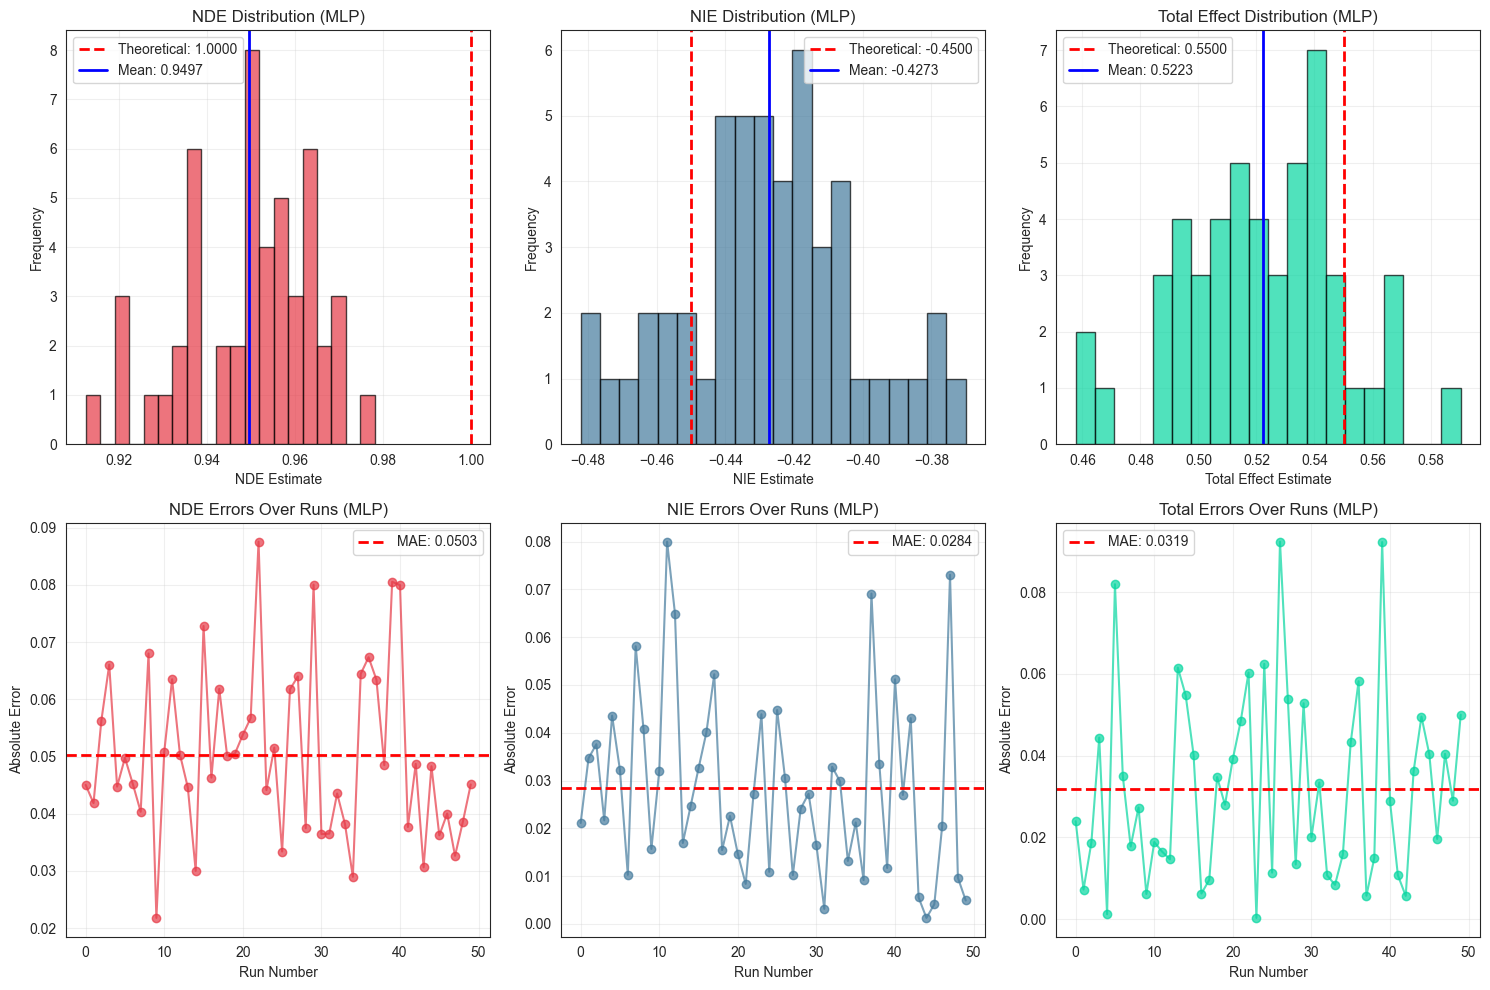


3. Model Comparison Summary:
Model      NDE MAE      NIE MAE      Total MAE    NDE MCE      NIE MCE     
--------------------------------------------------------------------------------
MLP        0.0503       0.0284       0.0319       0.0021       0.0036      


In [74]:
# Run Monte Carlo evaluation for both Linear and MLP models
print("Running Monte Carlo evaluation for NDE/NIE estimation...")

# Test with MLP models (as requested)
print("\n1. MLP Models (hidden_layer_sizes=(100,), max_iter=500):")
mlp_results = monte_carlo_nde_nie_evaluation(
    num_runs=50,  # Reduced for faster execution
    num_samples=7000,
    base_seed=42,
    model_type="mlp",
    hidden_layer_sizes=(100,),
    max_iter=500
)


# Compare results
print(f"\n3. Model Comparison Summary:")
print("="*80)
print(f"{'Model':<10} {'NDE MAE':<12} {'NIE MAE':<12} {'Total MAE':<12} {'NDE MCE':<12} {'NIE MCE':<12}")
print("-"*80)
print(f"{'MLP':<10} {mlp_results['nde_mae']:<12.4f} {mlp_results['nie_mae']:<12.4f} {mlp_results['total_mae']:<12.4f} {mlp_results['nde_mce']:<12.4f} {mlp_results['nie_mce']:<12.4f}")

# Determine which model performs better
mlp_total_mae = mlp_results['total_mae']

In [5]:
# E[Y|T=1,M=m] - E[Y|T=1,M=m'] = 1 - 0.8 * 0.5**2 - 0.5 * 1 * 0.5 - (1 )

treatment_col_index = 0
confounder_col_index = 1
mediator1_col_index = 2

def filter_close(X, col_idx, val, tol=0.1):
    return np.abs(X[:, col_idx] - val) < tol

In [22]:
def compute_path_wise_effects_reg(sample, custom_model, X_test1, treatment_col_index, mediator_col_index, confounder_col_index):
    # Predict initial outcomes using the custom model (usually on full X_test1)
    y_hat_model = custom_model.predict(X_test1)
    T_test1 = X_test1[:, treatment_col_index]

    def train_inner_models(X, y, T):
        """
        Train T-learner models using treated and control splits with poly2 features,
        excluding treatment column from features.
        """
        # Remove treatment column from features to avoid leakage
        X_no_treatment = np.delete(X, treatment_col_index, axis=1)

        X_treated = X_no_treatment[T == 1]
        y_treated = y[T == 1]
        X_control = X_no_treatment[T == 0]
        y_control = y[T == 0]

        # Use only poly2 models
        poly = PolynomialFeatures(degree=2, include_bias=False)
        model_mu1 = make_pipeline(poly, LinearRegression())
        model_mu1.fit(X_treated, y_treated)
        model_mu0 = make_pipeline(poly, LinearRegression())
        model_mu0.fit(X_control, y_control)

        return model_mu1, model_mu0

    def predict_cate(model_mu1, model_mu0, X):
        # Remove treatment column before prediction
        T = X[:, treatment_col_index]
        X_1 = X[T == 1]
        X_0 = X[T == 0]

        X_0=np.delete(X_0, treatment_col_index, axis=1)
        X_1=np.delete(X_1, treatment_col_index, axis=1)

        mu1 = model_mu1.predict(X_1)
        mu0 = model_mu0.predict(X_0)
        cate_mean = np.mean(mu1) - np.mean(mu0)
        return mu1, mu0, cate_mean

    # === Train models on full dataset ===
    model_mu1, model_mu0 = train_inner_models(X_test1, y_hat_model, T_test1)
    # === 1. Full data (mediator present) ===
    # E[Y | T = 1, C = c] - E[Y | T = 0, C = c] - ATE

    def filter_close(X, col_idx, val, tol=0.1):
        return np.abs(X[:, col_idx] - val) < tol

    mask_conf = filter_close(X_test1, confounder_col_index, sample[confounder_col_index])
    X_filtered_conf = X_test1[mask_conf]

    mu1_full, mu0_full, cate_all = predict_cate(model_mu1, model_mu0, X_filtered_conf)
    # Helper function for filtering samples close to sample value

    # === 2. Remove Mediator: filter by confounder only ===

    # E[Y | T = 1, M = m, C = c] - E[Y | T = 0, M = m, C = c] - CATE(m)
    mask_conf = (filter_close(X_test1, confounder_col_index, sample[confounder_col_index]) & 
                 filter_close(X_test1, mediator_col_index, sample[mediator_col_index]))
    X_filtered_conf = X_test1[mask_conf]
    mu1_conf, mu0_conf, cate_mediator = predict_cate(model_mu1, model_mu0, X_filtered_conf)

    # === Compute Path-wise SHAP values (effects) ===
    pishap_t_m_y = cate_all - cate_mediator

    return {
        "pishap_t_m_y": pishap_t_m_y,
        "cate_all": cate_all,
        "cate_mediator": cate_mediator
    }
    
    

In [23]:
X_test1, y_test1 = population_dataset_1(num_samples=10000)

# Define tolerance for floating point comparisons
tolerance = 0.01

# Define confounder column index (assuming it's at index 1 based on later usage)
confounder_col_index = 1

relevant_samples = X_test1[
    (np.abs(X_test1[:, treatment_col_index] - 1) < tolerance) & 
    (np.abs(X_test1[:, confounder_col_index] - 0) < tolerance) 
]

mediator_1_min = np.min(X_test1[:, mediator1_col_index])
mediator_1_max = np.max(X_test1[:, mediator1_col_index])

results = []
results_nie = []
for i in np.arange(mediator_1_min + 0.15, mediator_1_max - 0.15, 0.3):

    sample_local = np.array([1, 0.2, i, 1])

    # === 2. Remove Mediator 1: filter by mediator2 + confounder only ===
    mask_m1_c_t = (filter_close(X_test1, mediator1_col_index, sample_local[mediator1_col_index]) & \
                filter_close(X_test1, confounder_col_index, sample_local[confounder_col_index]) & \
                filter_close(X_test1, treatment_col_index, sample_local[treatment_col_index]))
    mask_m1_c_t0 = (filter_close(X_test1, mediator1_col_index, sample_local[mediator1_col_index]) & \
            filter_close(X_test1, confounder_col_index, sample_local[confounder_col_index]) & \
            filter_close(X_test1, treatment_col_index, 1 - sample_local[treatment_col_index]))
    
    
    if np.sum(mask_m1_c_t) == 0 or np.sum(mask_m1_c_t0) == 0:
        results.append(0)
        continue
    res = compute_path_wise_effects_reg(sample_local, ModelWrapperPopulation(), X_test1, treatment_col_index, mediator1_col_index, confounder_col_index)
    results.append(res["cate_mediator"])
    results_nie.append(res["pishap_t_m_y"])
    

In [31]:
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


def monte_carlo_causal_effects_evaluation(sampling_rates, effect_type="NDE", num_samples=10000, 
                                         num_runs=50, base_seed=42, model_cls=None, 
                                         true_value=None, title_suffix=""):
    """
    Perform Monte Carlo evaluation of causal effects across different seeds.
    
    Args:
        sampling_rates: List of sampling rates to test
        effect_type: "NDE" for Natural Direct Effect or "NIE" for Natural Indirect Effect
        num_samples: Number of samples per run for dataset generation
        num_runs: Number of Monte Carlo runs
        base_seed: Base seed for reproducibility (each run gets base_seed + run_number)
        model: Model to use for prediction (defaults to ModelWrapperPopulation if None)
        true_value: True value for comparison (if None, will be estimated from first run)
        title_suffix: Optional string to append to plot titles
    
    Returns:
        Dictionary with results and statistics
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    print(f"Monte Carlo evaluation of {effect_type} across {num_runs} runs...")
    print("="*70)
    
    # Use provided model or default to ModelWrapperPopulation
    # Store results for each run
    all_results = []
    individual_estimates = []
    
    for run in range(num_runs):
        print(f"Run {run + 1}/{num_runs}", end="\r")
        
        # Set seed for this run
        np.random.seed(base_seed + run)
        
        # Generate data for this run
        X_test1, y_test1 = population_dataset_1(num_samples=num_samples, seed=run)
        
        if  issubclass(model_cls, MLPRegressor):
            model = model_cls(hidden_layer_sizes=(100,), max_iter=500, random_state=run).fit(X_test1, y_test1)

        elif issubclass(model_cls, XGBRegressor):
            model = model_cls(random_state=run).fit(X_test1, y_test1)
        
        elif issubclass(model_cls, LinearRegression):
            model = model_cls().fit(X_test1, y_test1)
        elif issubclass(model_cls, ModelWrapperPopulation):
            model = ModelWrapperPopulation()
        # Get mediator range
        mediator_1_min = np.min(X_test1[:, mediator1_col_index])
        mediator_1_max = np.max(X_test1[:, mediator1_col_index])
        
        # Compute results for each sampling rate
        run_results = []
        for sampling_rate in sampling_rates:
            start_point = mediator_1_min + sampling_rate/2
            end_point = mediator_1_max - sampling_rate/2
            
            # Generate samples with current sampling rate
            individual_results = []
            for i in np.arange(start_point, end_point, sampling_rate):
                sample_local = np.array([1, 0.2, i, 1])
                
                # Filter by confounder only
                mask_conf = filter_close(X_test1, confounder_col_index, sample_local[confounder_col_index])
                
                if np.sum(mask_conf) == 0:
                    individual_results.append(0)
                    continue
                    
                try:
                    res = compute_path_wise_effects_reg(
                        sample_local, 
                        model, 
                        X_test1, 
                        treatment_col_index, 
                        mediator1_col_index, 
                        confounder_col_index
                    )
                    
                    # Choose effect type
                    if effect_type == "NDE":
                        effect_value = res["cate_mediator"]
                    elif effect_type == "NIE":
                        effect_value = res["pishap_t_m_y"]
                    else:
                        raise ValueError(f"Invalid effect_type: {effect_type}. Use 'NDE' or 'NIE'")
                    
                    individual_results.append(effect_value)
                    
                except Exception as e:
                    individual_results.append(0)
            
            # Compute probability weights for mediator (FIXED: was using confounder before)
            probs_mediator = []
            mask_t0_z0 = (
                (X_test1[:, 0] == 0) &  # T=0 (control group)
                (np.abs(X_test1[:, confounder_col_index] - 0.2) < 0.01)  # Z=0.2
            )
            
            if np.sum(mask_t0_z0) == 0:
                probs_mediator = [0] * len(individual_results)
            else:
                mediator_values_t0_z0 = X_test1[mask_t0_z0, mediator1_col_index]
                tolerance = sampling_rate / 2
                
                for mediator_value in np.arange(start_point, end_point, sampling_rate):
                    count_m1 = np.sum(np.abs(mediator_values_t0_z0 - mediator_value) < tolerance)
                    total_count = len(mediator_values_t0_z0)
                    prob_m1 = count_m1 / total_count if total_count > 0 else 0
                    probs_mediator.append(prob_m1)
            
            # Ensure same length
            min_len = min(len(individual_results), len(probs_mediator))
            individual_results = individual_results[:min_len]
            probs_mediator = probs_mediator[:min_len]
            
            # Compute weighted effect for this sampling rate
            weighted_effect = np.sum([eff * prob for eff, prob in zip(individual_results, probs_mediator)])
            run_results.append(weighted_effect)
        
        all_results.append(run_results)
        individual_estimates.extend(run_results)
    
    print(f"\nCompleted {num_runs} runs")
    
    # Convert to numpy array for easier computation
    all_results = np.array(all_results)  # Shape: (num_runs, len(sampling_rates))
    
    # Compute statistics across runs
    mean_results = np.mean(all_results, axis=0)
    std_results = np.std(all_results, axis=0)
    monte_carlo_errors = std_results / np.sqrt(num_runs)
    
    # Estimate true value if not provided
    if true_value is None:
        true_value = np.mean(mean_results)
        print(f"Estimated true value: {true_value:.4f}")
    
    # Compute errors
    errors = all_results - true_value
    mae = np.mean(np.abs(errors), axis=0)
    
    # Create results dictionary
    results = {
        'sampling_rates': sampling_rates,
        'mean_results': mean_results,
        'std_results': std_results,
        'monte_carlo_errors': monte_carlo_errors,
        'mae': mae,
        'true_value': true_value,
        'all_runs': all_results,
        'effect_type': effect_type,
        'num_runs': num_runs
    }
    
    # Display results
    print(f"\n{effect_type} Results Summary{title_suffix}:")
    print("="*60)
    print(f"{'Sampling Rate':<15} {'Mean':<12} {'Std':<12} {'MCE':<12} {'MAE':<12}")
    print("-"*60)
    for i, rate in enumerate(sampling_rates):
        print(f"{rate:<15.1f} {mean_results[i]:<12.4f} {std_results[i]:<12.4f} "
              f"{monte_carlo_errors[i]:<12.4f} {mae[i]:<12.4f}")
    
    # Visualization
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Mean results with error bars
    plt.subplot(1, 3, 1)
    plt.errorbar(sampling_rates, mean_results, yerr=monte_carlo_errors, 
                fmt='o-', linewidth=2, markersize=8, capsize=5, 
                color='#E63946', label=f'{effect_type} (Mean ± MCE)')
    plt.axhline(y=true_value, color='black', linestyle='--', linewidth=2, 
                label=f'True Value: {true_value:.4f}')
    plt.xlabel('Sampling Rate', fontsize=12, fontweight='bold')
    plt.ylabel(f'{effect_type} Value', fontsize=12, fontweight='bold')
    plt.title(f'{effect_type} vs Sampling Rate{title_suffix}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Plot 2: MAE vs Sampling Rate
    plt.subplot(1, 3, 2)
    plt.plot(sampling_rates, mae, 's-', linewidth=2, markersize=8, 
             color='#457B9D', label='Mean Absolute Error')
    plt.xlabel('Sampling Rate', fontsize=12, fontweight='bold')
    plt.ylabel('MAE', fontsize=12, fontweight='bold')
    plt.title(f'MAE vs Sampling Rate{title_suffix}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Distribution of estimates
    plt.subplot(1, 3, 3)
    plt.hist(individual_estimates, bins=20, alpha=0.7, color='#06D6A0', 
             edgecolor='black', linewidth=1)
    plt.axvline(true_value, color='red', linestyle='--', linewidth=2, 
                label=f'True Value: {true_value:.4f}')
    plt.axvline(np.mean(individual_estimates), color='blue', linestyle='-', linewidth=2, 
                label=f'Mean: {np.mean(individual_estimates):.4f}')
    plt.xlabel(f'{effect_type} Value', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title(f'Distribution of {effect_type} Estimates{title_suffix}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results


Monte Carlo evaluation example...

1. Evaluating NDE (Natural Direct Effect):
Monte Carlo evaluation of NDE across 50 runs...
Run 50/50
Completed 50 runs

NDE Results Summary - NDE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             0.9545       0.0483       0.0068       0.0542      
0.1             0.9551       0.0503       0.0071       0.0546      
0.1             0.9515       0.0508       0.0072       0.0562      
0.2             0.9489       0.0523       0.0074       0.0585      
0.2             0.9576       0.0442       0.0063       0.0501      
0.3             0.9503       0.0554       0.0078       0.0578      
0.3             0.9609       0.0474       0.0067       0.0502      
0.4             0.9513       0.0528       0.0075       0.0580      
0.5             0.9466       0.0550       0.0078       0.0602      
0.5             0.9401       0.0600       0.0085       0.0704      


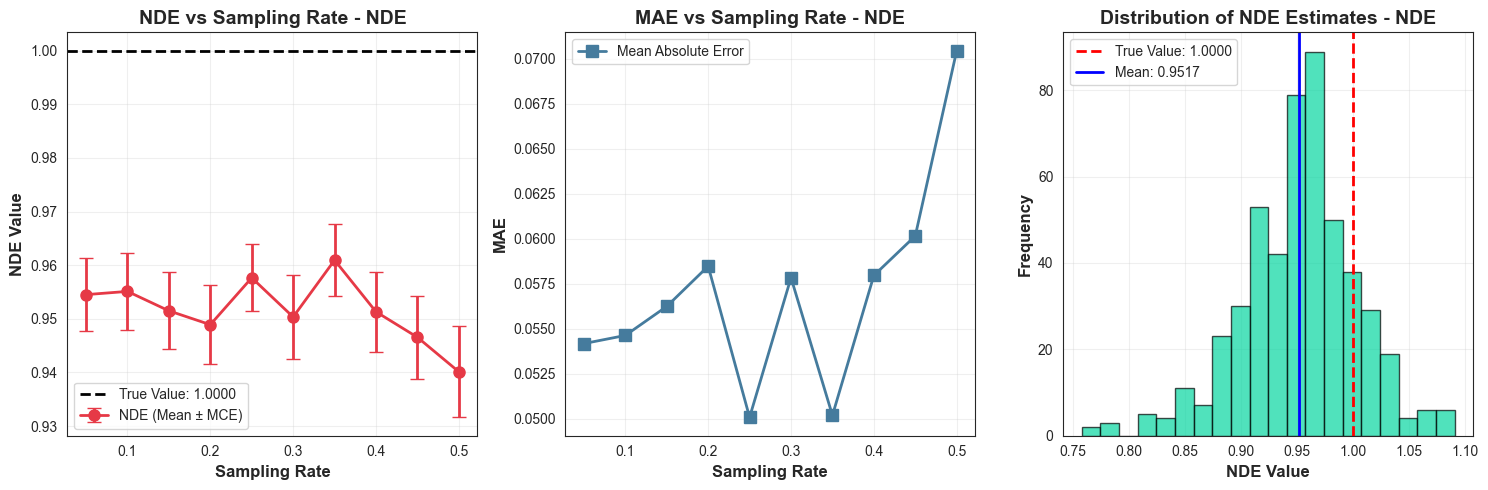


2. Evaluating NIE (Natural Indirect Effect):
Monte Carlo evaluation of NIE across 50 runs...
Run 50/50
Completed 50 runs

NIE Results Summary - NIE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             -0.4295      0.0444       0.0063       0.0397      
0.1             -0.4297      0.0446       0.0063       0.0407      
0.1             -0.4271      0.0442       0.0063       0.0410      
0.2             -0.4256      0.0472       0.0067       0.0431      
0.2             -0.4319      0.0451       0.0064       0.0376      
0.3             -0.4265      0.0463       0.0065       0.0428      
0.3             -0.4361      0.0469       0.0066       0.0401      
0.4             -0.4285      0.0477       0.0068       0.0417      
0.5             -0.4240      0.0477       0.0067       0.0426      
0.5             -0.4212      0.0493       0.0070       0.0489      


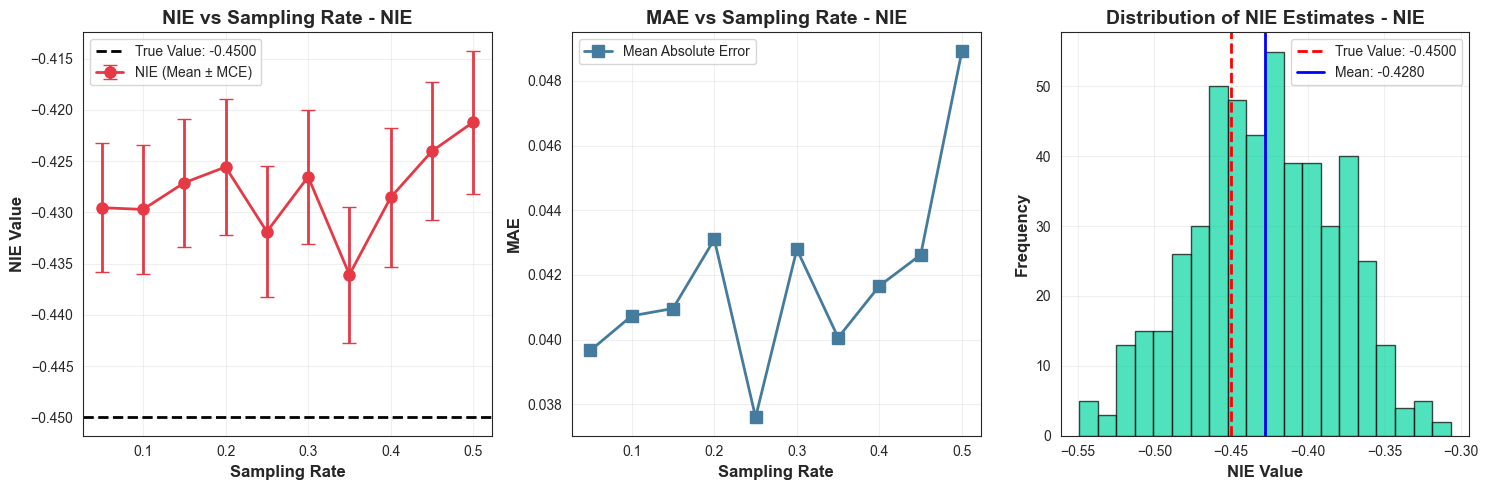


3. Comparison Summary:
NDE True Value: 1.0000
NIE True Value: -0.4500
Total Effect: 0.5500

Best sampling rate for NDE: 0.25 (MAE: 0.0501)
Best sampling rate for NIE: 0.25 (MAE: 0.0376)


In [50]:
# Example: Monte Carlo evaluation with different seeds
print("Monte Carlo evaluation example...")

# Define sampling rates to test
sampling_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

# Run Monte Carlo evaluation for NDE
print("\n1. Evaluating NDE (Natural Direct Effect):")
nde_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NDE",
    num_samples=7000,
    model_cls=ModelWrapperPopulation,
    num_runs=50,  # Reduced for faster execution
    base_seed=42,
    true_value=theoretical_NDE,  # Will be estimated
    title_suffix=" - NDE"
)

# Run Monte Carlo evaluation for NIE
print("\n2. Evaluating NIE (Natural Indirect Effect):")
nie_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NIE",
    num_samples=7000,
    num_runs=50,
    base_seed=42,
    model_cls=ModelWrapperPopulation,
    true_value=theoretical_NIE,
    title_suffix=" - NIE"
)

# Compare results
print(f"\n3. Comparison Summary:")
print("="*50)
print(f"NDE True Value: {nde_mc_results['true_value']:.4f}")
print(f"NIE True Value: {nie_mc_results['true_value']:.4f}")
print(f"Total Effect: {nde_mc_results['true_value'] + nie_mc_results['true_value']:.4f}")

# Find best sampling rate for each effect
best_nde_idx = np.argmin(nde_mc_results['mae'])
best_nie_idx = np.argmin(nie_mc_results['mae'])

print(f"\nBest sampling rate for NDE: {sampling_rates[best_nde_idx]} (MAE: {nde_mc_results['mae'][best_nde_idx]:.4f})")
print(f"Best sampling rate for NIE: {sampling_rates[best_nie_idx]} (MAE: {nie_mc_results['mae'][best_nie_idx]:.4f})")


mae_nde_gt = nde_mc_results['mae']
mae_nie_gt = nie_mc_results['mae']


Monte Carlo evaluation example...

1. Evaluating NDE (Natural Direct Effect):
Monte Carlo evaluation of NDE across 50 runs...
Run 50/50
Completed 50 runs

NDE Results Summary - NDE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             0.9581       0.0491       0.0069       0.0523      
0.1             0.9587       0.0511       0.0072       0.0525      
0.1             0.9551       0.0514       0.0073       0.0543      
0.2             0.9524       0.0528       0.0075       0.0563      
0.2             0.9613       0.0447       0.0063       0.0478      
0.3             0.9538       0.0562       0.0079       0.0560      
0.3             0.9647       0.0483       0.0068       0.0482      
0.4             0.9549       0.0535       0.0076       0.0554      
0.5             0.9501       0.0557       0.0079       0.0581      
0.5             0.9437       0.0609       0.0086       0.0684      


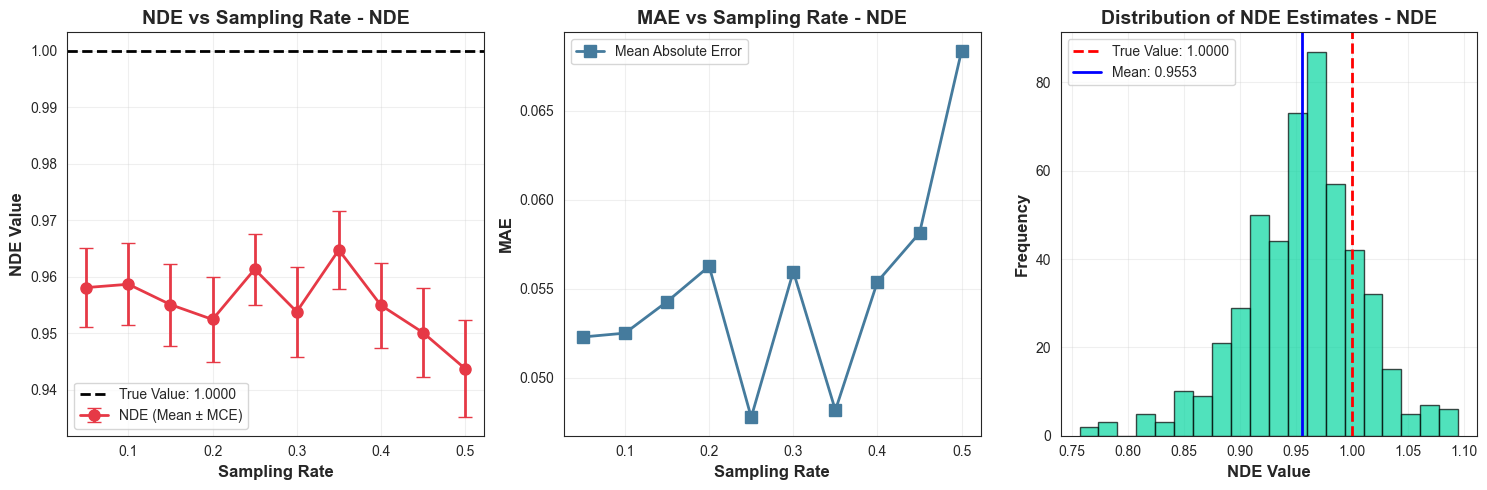


2. Evaluating NIE (Natural Indirect Effect):
Monte Carlo evaluation of NIE across 50 runs...
Run 50/50
Completed 50 runs

NIE Results Summary - NIE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             -0.4307      0.0449       0.0063       0.0395      
0.1             -0.4308      0.0452       0.0064       0.0404      
0.1             -0.4282      0.0447       0.0063       0.0406      
0.2             -0.4267      0.0476       0.0067       0.0426      
0.2             -0.4331      0.0457       0.0065       0.0374      
0.3             -0.4276      0.0469       0.0066       0.0427      
0.3             -0.4374      0.0472       0.0067       0.0397      
0.4             -0.4297      0.0481       0.0068       0.0415      
0.5             -0.4252      0.0485       0.0069       0.0428      
0.5             -0.4224      0.0502       0.0071       0.0488      


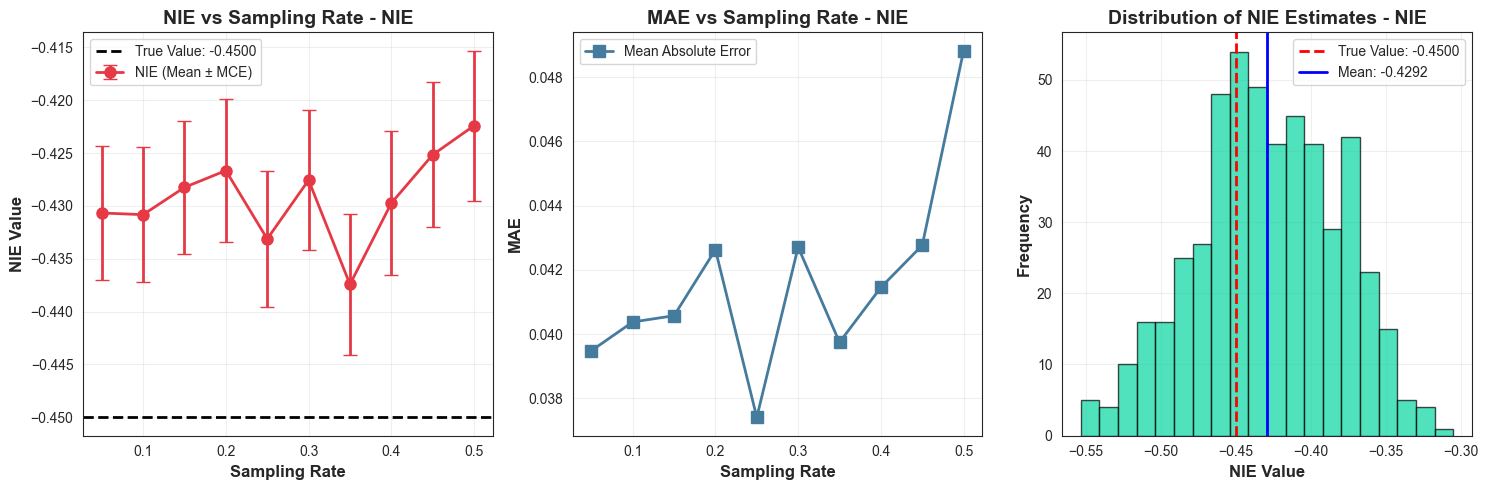


3. Comparison Summary:
NDE True Value: 1.0000
NIE True Value: -0.4500
Total Effect: 0.5500

Best sampling rate for NDE: 0.25 (MAE: 0.0478)
Best sampling rate for NIE: 0.25 (MAE: 0.0374)


In [51]:

# Example: Monte Carlo evaluation with different seeds
print("Monte Carlo evaluation example...")

# Define sampling rates to test
sampling_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

# Run Monte Carlo evaluation for NDE
print("\n1. Evaluating NDE (Natural Direct Effect):")
nde_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NDE",
    num_samples=7000,
    num_runs=50,  # Reduced for faster execution
    base_seed=42,
    model_cls=MLPRegressor,  # Uses ModelWrapperPopulation
    true_value=theoretical_NDE,  # Will be estimated
    title_suffix=" - NDE"
)

# Run Monte Carlo evaluation for NIE
print("\n2. Evaluating NIE (Natural Indirect Effect):")
nie_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NIE",
    num_samples=7000,
    num_runs=50,
    base_seed=42,
    model_cls=MLPRegressor,
    true_value=theoretical_NIE,
    title_suffix=" - NIE"
)


# Compare results
print(f"\n3. Comparison Summary:")
print("="*50)
print(f"NDE True Value: {nde_mc_results['true_value']:.4f}")
print(f"NIE True Value: {nie_mc_results['true_value']:.4f}")
print(f"Total Effect: {nde_mc_results['true_value'] + nie_mc_results['true_value']:.4f}")

# Find best sampling rate for each effect
best_nde_idx = np.argmin(nde_mc_results['mae'])
best_nie_idx = np.argmin(nie_mc_results['mae'])

print(f"\nBest sampling rate for NDE: {sampling_rates[best_nde_idx]} (MAE: {nde_mc_results['mae'][best_nde_idx]:.4f})")
print(f"Best sampling rate for NIE: {sampling_rates[best_nie_idx]} (MAE: {nie_mc_results['mae'][best_nie_idx]:.4f})")

mae_nde_mlp = nde_mc_results['mae']
mae_nie_mlp = nie_mc_results['mae']



Monte Carlo evaluation example...

1. Evaluating NDE (Natural Direct Effect):
Monte Carlo evaluation of NDE across 50 runs...
Run 50/50
Completed 50 runs

NDE Results Summary - NDE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             0.9545       0.0484       0.0068       0.0542      
0.1             0.9551       0.0504       0.0071       0.0547      
0.1             0.9515       0.0509       0.0072       0.0563      
0.2             0.9489       0.0524       0.0074       0.0585      
0.2             0.9577       0.0443       0.0063       0.0501      
0.3             0.9504       0.0555       0.0078       0.0579      
0.3             0.9610       0.0475       0.0067       0.0502      
0.4             0.9514       0.0528       0.0075       0.0580      
0.5             0.9466       0.0551       0.0078       0.0602      
0.5             0.9402       0.0601       0.0085       0.0705      


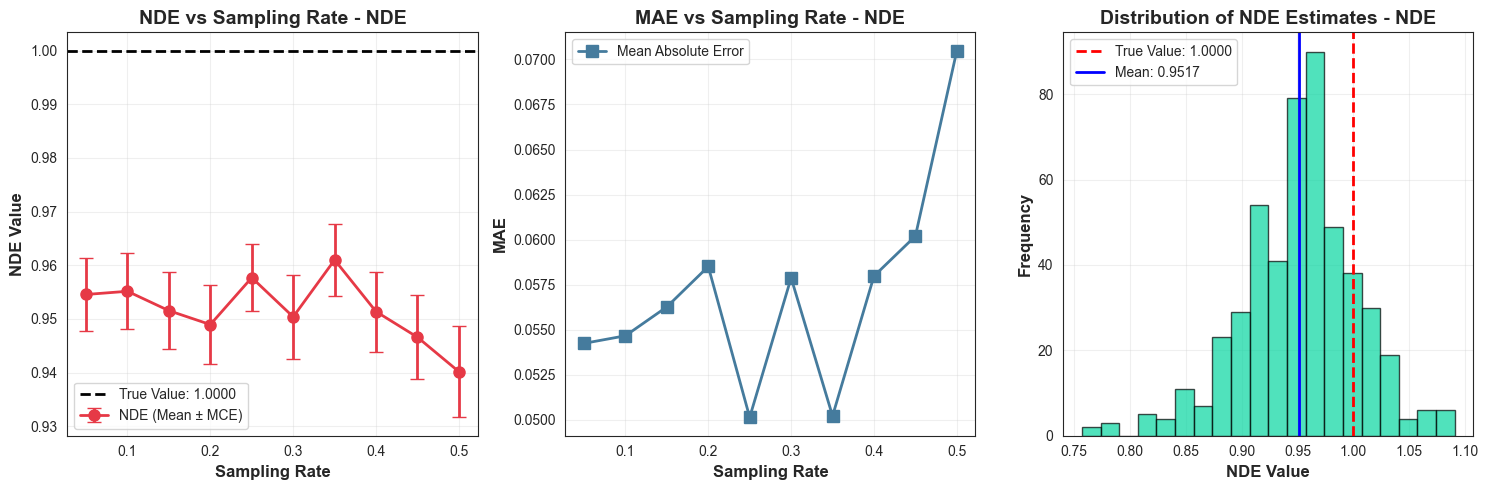


2. Evaluating NIE (Natural Indirect Effect):
Monte Carlo evaluation of NIE across 50 runs...
Run 50/50
Completed 50 runs

NIE Results Summary - NIE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             -0.4298      0.0444       0.0063       0.0396      
0.1             -0.4300      0.0447       0.0063       0.0407      
0.1             -0.4274      0.0443       0.0063       0.0409      
0.2             -0.4259      0.0473       0.0067       0.0430      
0.2             -0.4322      0.0451       0.0064       0.0376      
0.3             -0.4268      0.0464       0.0066       0.0427      
0.3             -0.4364      0.0469       0.0066       0.0400      
0.4             -0.4288      0.0478       0.0068       0.0416      
0.5             -0.4243      0.0478       0.0068       0.0425      
0.5             -0.4215      0.0494       0.0070       0.0489      


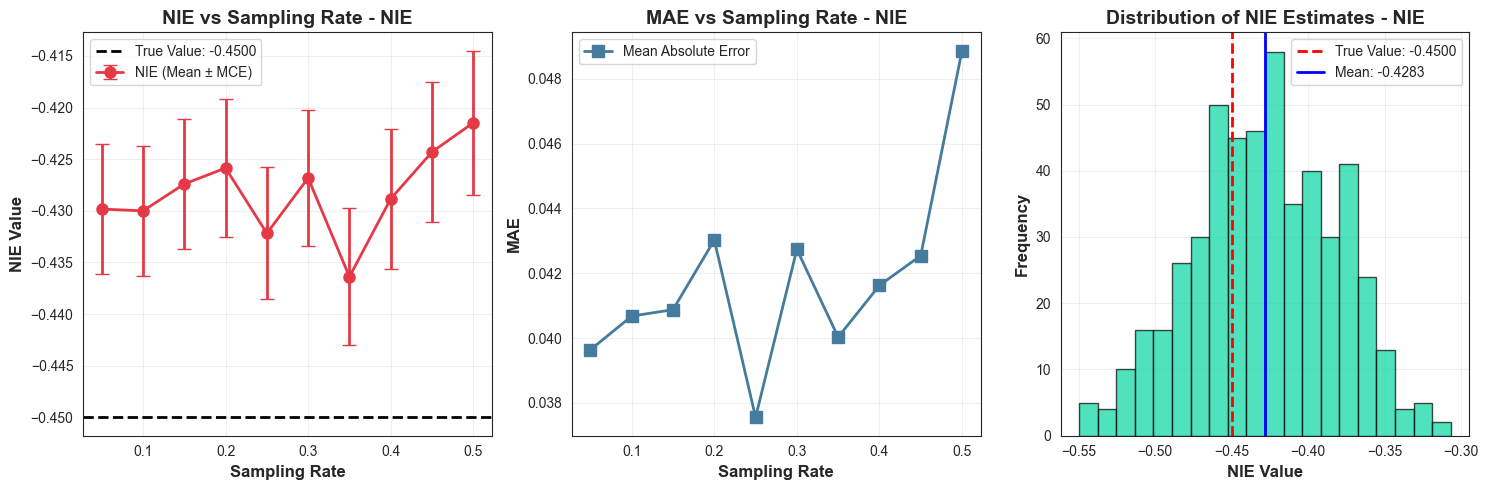


3. Comparison Summary:
NDE True Value: 1.0000
NIE True Value: -0.4500
Total Effect: 0.5500

Best sampling rate for NDE: 0.25 (MAE: 0.0501)
Best sampling rate for NIE: 0.25 (MAE: 0.0376)


In [52]:

# Example: Monte Carlo evaluation with different seeds
print("Monte Carlo evaluation example...")

# Define sampling rates to test
sampling_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

# Run Monte Carlo evaluation for NDE
print("\n1. Evaluating NDE (Natural Direct Effect):")
nde_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NDE",
    num_samples=7000,
    num_runs=50,  # Reduced for faster execution
    base_seed=42,
    model_cls=XGBRegressor,  # Uses ModelWrapperPopulation
    true_value=theoretical_NDE,  # Will be estimated
    title_suffix=" - NDE"
)

# Run Monte Carlo evaluation for NIE
print("\n2. Evaluating NIE (Natural Indirect Effect):")
nie_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NIE",
    num_samples=7000,
    num_runs=50,
    base_seed=42,
    model_cls=XGBRegressor,
    true_value=theoretical_NIE,
    title_suffix=" - NIE"
)


# Compare results
print(f"\n3. Comparison Summary:")
print("="*50)
print(f"NDE True Value: {nde_mc_results['true_value']:.4f}")
print(f"NIE True Value: {nie_mc_results['true_value']:.4f}")
print(f"Total Effect: {nde_mc_results['true_value'] + nie_mc_results['true_value']:.4f}")

# Find best sampling rate for each effect
best_nde_idx = np.argmin(nde_mc_results['mae'])
best_nie_idx = np.argmin(nie_mc_results['mae'])

print(f"\nBest sampling rate for NDE: {sampling_rates[best_nde_idx]} (MAE: {nde_mc_results['mae'][best_nde_idx]:.4f})")
print(f"Best sampling rate for NIE: {sampling_rates[best_nie_idx]} (MAE: {nie_mc_results['mae'][best_nie_idx]:.4f})")

mae_nde_xgb = nde_mc_results['mae']
mae_nie_xgb = nie_mc_results['mae']

Monte Carlo evaluation example...

1. Evaluating NDE (Natural Direct Effect):
Monte Carlo evaluation of NDE across 50 runs...
Run 50/50
Completed 50 runs

NDE Results Summary - NDE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             0.8434       0.0218       0.0031       0.1566      
0.1             0.8435       0.0228       0.0032       0.1565      
0.1             0.8421       0.0247       0.0035       0.1579      
0.2             0.8401       0.0252       0.0036       0.1599      
0.2             0.8438       0.0207       0.0029       0.1562      
0.3             0.8400       0.0266       0.0038       0.1600      
0.3             0.8441       0.0225       0.0032       0.1559      
0.4             0.8395       0.0267       0.0038       0.1605      
0.5             0.8395       0.0297       0.0042       0.1605      
0.5             0.8344       0.0329       0.0047       0.1656      


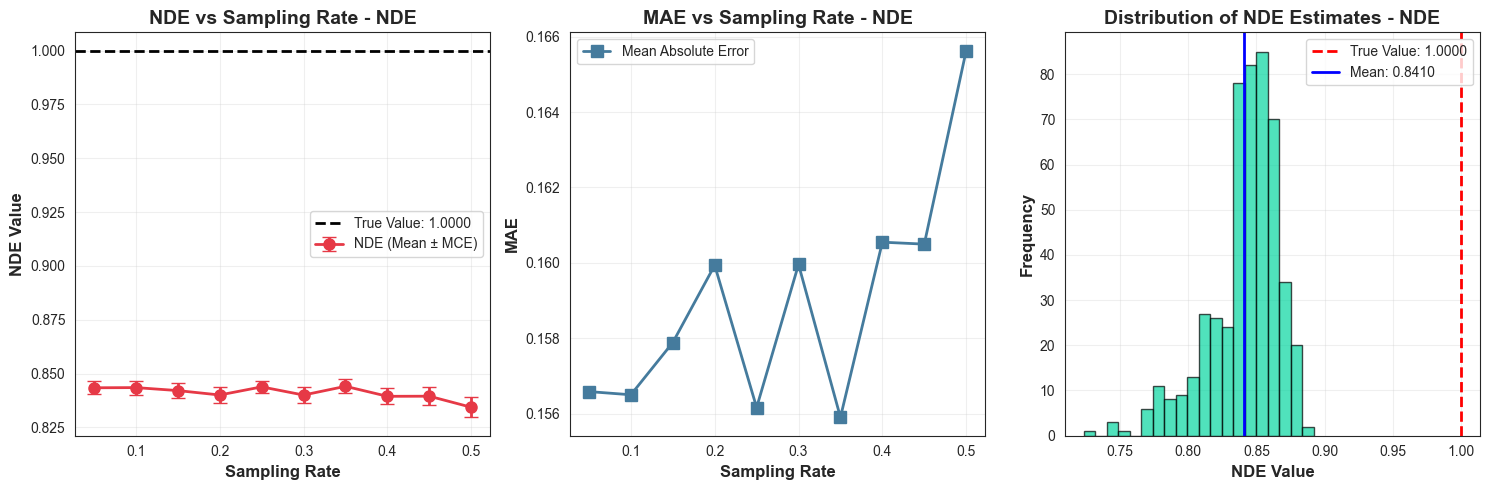


2. Evaluating NIE (Natural Indirect Effect):
Monte Carlo evaluation of NIE across 50 runs...
Run 50/50
Completed 50 runs

NIE Results Summary - NIE:
Sampling Rate   Mean         Std          MCE          MAE         
------------------------------------------------------------
0.1             -0.3163      0.0232       0.0033       0.1337      
0.1             -0.3160      0.0233       0.0033       0.1340      
0.1             -0.3156      0.0241       0.0034       0.1344      
0.2             -0.3145      0.0235       0.0033       0.1355      
0.2             -0.3158      0.0236       0.0033       0.1342      
0.3             -0.3142      0.0241       0.0034       0.1358      
0.3             -0.3170      0.0236       0.0033       0.1330      
0.4             -0.3145      0.0254       0.0036       0.1355      
0.5             -0.3148      0.0239       0.0034       0.1352      
0.5             -0.3134      0.0268       0.0038       0.1366      


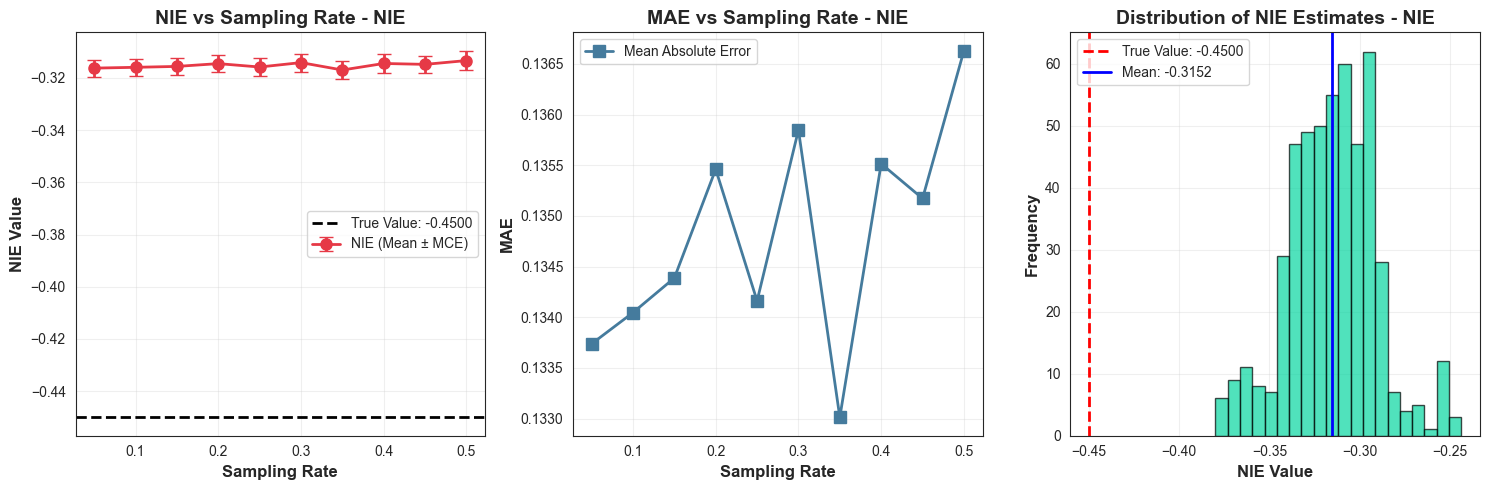


3. Comparison Summary:
NDE True Value: 1.0000
NIE True Value: -0.4500
Total Effect: 0.5500

Best sampling rate for NDE: 0.35 (MAE: 0.1559)
Best sampling rate for NIE: 0.35 (MAE: 0.1330)


In [53]:

# Example: Monte Carlo evaluation with different seeds
print("Monte Carlo evaluation example...")

# Define sampling rates to test
sampling_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

# Run Monte Carlo evaluation for NDE
print("\n1. Evaluating NDE (Natural Direct Effect):")
nde_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NDE",
    num_samples=7000,
    num_runs=50,  # Reduced for faster execution
    base_seed=42,
    model_cls=LinearRegression,  # Uses ModelWrapperPopulation
    true_value=theoretical_NDE,  # Will be estimated
    title_suffix=" - NDE"
)

# Run Monte Carlo evaluation for NIE
print("\n2. Evaluating NIE (Natural Indirect Effect):")
nie_mc_results = monte_carlo_causal_effects_evaluation(
    sampling_rates=sampling_rates,
    effect_type="NIE",
    num_samples=7000,
    num_runs=50,
    base_seed=42,
    model_cls=LinearRegression,
    true_value=theoretical_NIE,
    title_suffix=" - NIE"
)


# Compare results
print(f"\n3. Comparison Summary:")
print("="*50)
print(f"NDE True Value: {nde_mc_results['true_value']:.4f}")
print(f"NIE True Value: {nie_mc_results['true_value']:.4f}")
print(f"Total Effect: {nde_mc_results['true_value'] + nie_mc_results['true_value']:.4f}")

# Find best sampling rate for each effect
best_nde_idx = np.argmin(nde_mc_results['mae'])
best_nie_idx = np.argmin(nie_mc_results['mae'])

print(f"\nBest sampling rate for NDE: {sampling_rates[best_nde_idx]} (MAE: {nde_mc_results['mae'][best_nde_idx]:.4f})")
print(f"Best sampling rate for NIE: {sampling_rates[best_nie_idx]} (MAE: {nie_mc_results['mae'][best_nie_idx]:.4f})")

mae_nde_lr = nde_mc_results['mae']
mae_nie_lr = nie_mc_results['mae']

In [61]:
def plot_mae_vs_sampling_rate(sampling_rates, mae_lists, model_names, title="MAE vs Sampling Rate Comparison"):
    """
    Plot MAE against sampling rate for multiple models.
    
    Args:
        sampling_rates: List of sampling rates
        mae_lists: List of MAE arrays, one for each model
        model_names: List of model names corresponding to mae_lists
        title: Title for the plot
    
    Returns:
        Dictionary with summary statistics
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Validate inputs
    if len(mae_lists) != len(model_names):
        raise ValueError("Number of MAE lists must match number of model names")
    
    if len(mae_lists) == 0:
        raise ValueError("At least one MAE list is required")
    
    # Check that all MAE lists have the same length as sampling_rates
    for i, mae_list in enumerate(mae_lists):
        if len(mae_list) != len(sampling_rates):
            raise ValueError(f"MAE list {i} has length {len(mae_list)} but sampling_rates has length {len(sampling_rates)}")
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Define colors for different models
    colors = ['#E63946', '#457B9D', '#06D6A0', '#F77F00', '#A23B72', '#2E86AB', '#A23B72', '#8B5A2B']
    
    # Main plot: MAE vs Sampling Rate
    plt.subplot(2, 2, 1)
    for i, mae_list in enumerate(mae_lists):
        model_name = model_names[i] if i < len(model_names) else f"Model_{i+1}"
        color = colors[i % len(colors)]
        plt.plot(sampling_rates, mae_list, 'o-', linewidth=2, markersize=6, 
                color=color, label=model_name, alpha=0.8)
    
    plt.xlabel('Sampling Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
    plt.title(f'{title} - MAE vs Sampling Interval', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')  # Log scale for better visualization
    
    # Set x-axis ticks to show exact sampling rate values
    plt.xticks(sampling_rates, [f'{rate:.2f}' for rate in sampling_rates])
    
    # Bar chart comparison
    plt.subplot(2, 2, 2)
    x = np.arange(len(sampling_rates))
    width = 0.8 / len(mae_lists)
    
    for i, mae_list in enumerate(mae_lists):
        model_name = model_names[i] if i < len(model_names) else f"Model_{i+1}"
        color = colors[i % len(colors)]
        plt.bar(x + i * width, mae_list, width, 
               label=model_name, color=color, alpha=0.7)
    
    plt.xlabel('Sampling Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
    plt.title(f'{title} - MAE by Sampling Interval', fontsize=14, fontweight='bold')
    plt.xticks(x + width * (len(mae_lists) - 1) / 2, 
               [f'{rate:.2f}' for rate in sampling_rates])
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3, axis='y')
    plt.yscale('log')
    
    # Average MAE comparison
    plt.subplot(2, 2, 3)
    avg_maes = [np.mean(mae_list) for mae_list in mae_lists]
    
    bars = plt.bar(model_names, avg_maes, color=colors[:len(model_names)], alpha=0.7)
    plt.xlabel('Model', fontsize=12, fontweight='bold')
    plt.ylabel('Average MAE', fontsize=12, fontweight='bold')
    plt.title(f'{title} - Average MAE Across All Sampling Rates', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.yscale('log')
    
    # Add value labels on bars
    for bar, val in zip(bars, avg_maes):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # MAE improvement over sampling rates
    plt.subplot(2, 2, 4)
    for i, mae_list in enumerate(mae_lists):
        model_name = model_names[i] if i < len(model_names) else f"Model_{i+1}"
        color = colors[i % len(colors)]
        # Calculate improvement (first rate vs last rate)
        if mae_list[0] > 0:  # Avoid division by zero
            improvement = (mae_list[0] - mae_list[-1]) / mae_list[0] * 100
        else:
            improvement = 0
        plt.plot(sampling_rates, mae_list, 'o-', linewidth=2, markersize=6, 
                color=color, label=f'{model_name} (Δ: {improvement:.1f}%)', alpha=0.8)
    
    plt.xlabel('Sampling Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
    plt.title(f'{title} - MAE Improvement', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Set x-axis ticks to show exact sampling rate values
    plt.xticks(sampling_rates, [f'{rate:.2f}' for rate in sampling_rates])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{title} - Summary Statistics:")
    print("="*80)
    print(f"{'Model':<20} {'Avg MAE':<12} {'Min MAE':<12} {'Max MAE':<12} {'Improvement':<12}")
    print("-"*80)
    
    summary_stats = {}
    for i, mae_list in enumerate(mae_lists):
        # Extract model name from the list index
        model_name = model_names[i] if i < len(model_names) else f"Model_{i+1}"
        
        avg_mae = np.mean(mae_list)
        min_mae = np.min(mae_list)
        max_mae = np.max(mae_list)
        
        if mae_list[0] > 0:
            improvement = (mae_list[0] - mae_list[-1]) / mae_list[0] * 100
        else:
            improvement = 0
        
        print(f"{model_name:<20} {avg_mae:<12.4f} {min_mae:<12.4f} {max_mae:<12.4f} {improvement:<12.1f}%")
        
        summary_stats[model_name] = {
            'avg_mae': avg_mae,
            'min_mae': min_mae,
            'max_mae': max_mae,
            'improvement': improvement,
            'mae_values': mae_list
        }
    
    # Find best model
    best_model = min(summary_stats.keys(), key=lambda x: summary_stats[x]['avg_mae'])
    print(f"\nBest Model: {best_model} (Avg MAE: {summary_stats[best_model]['avg_mae']:.4f})")
    
    return summary_stats


Example: MAE comparison across different models...

1. NDE (Natural Direct Effect) Comparison:


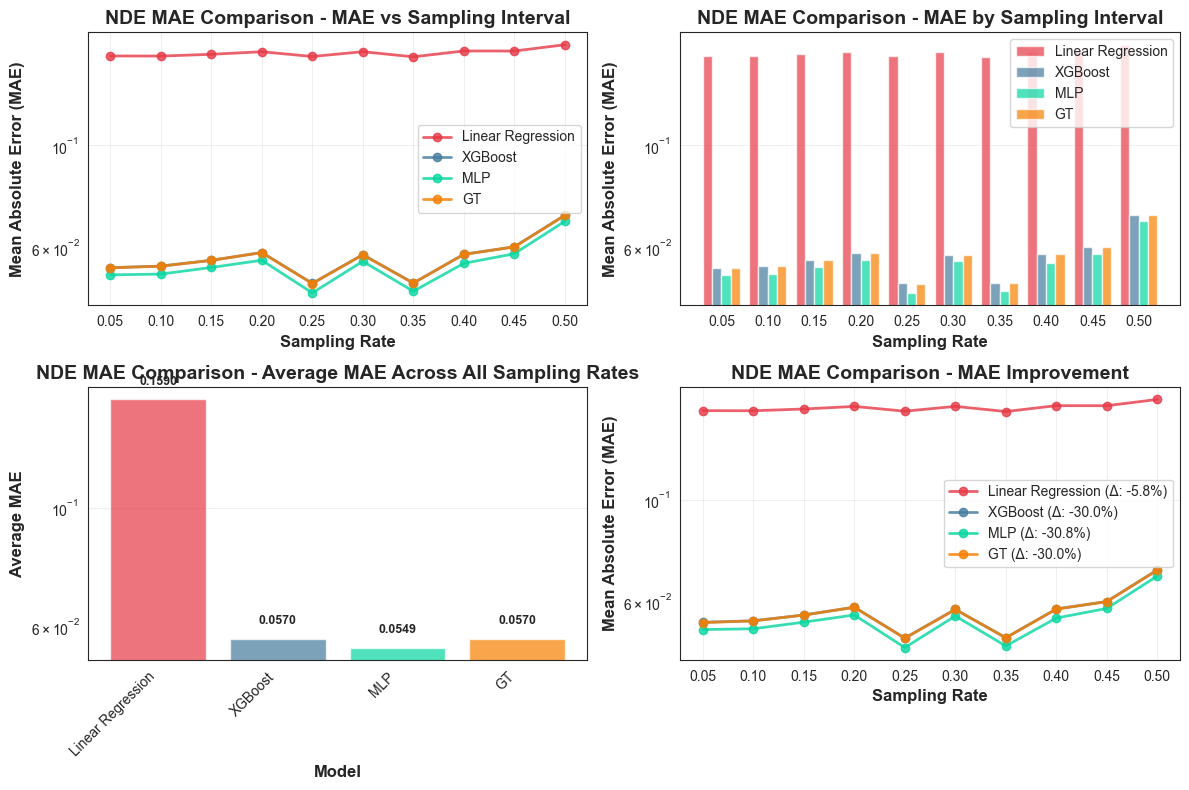


NDE MAE Comparison - Summary Statistics:
Model                Avg MAE      Min MAE      Max MAE      Improvement 
--------------------------------------------------------------------------------
Linear Regression    0.1590       0.1559       0.1656       -5.8        %
XGBoost              0.0570       0.0501       0.0705       -30.0       %
MLP                  0.0549       0.0478       0.0684       -30.8       %
GT                   0.0570       0.0501       0.0704       -30.0       %

Best Model: MLP (Avg MAE: 0.0549)

2. NIE (Natural Indirect Effect) Comparison:


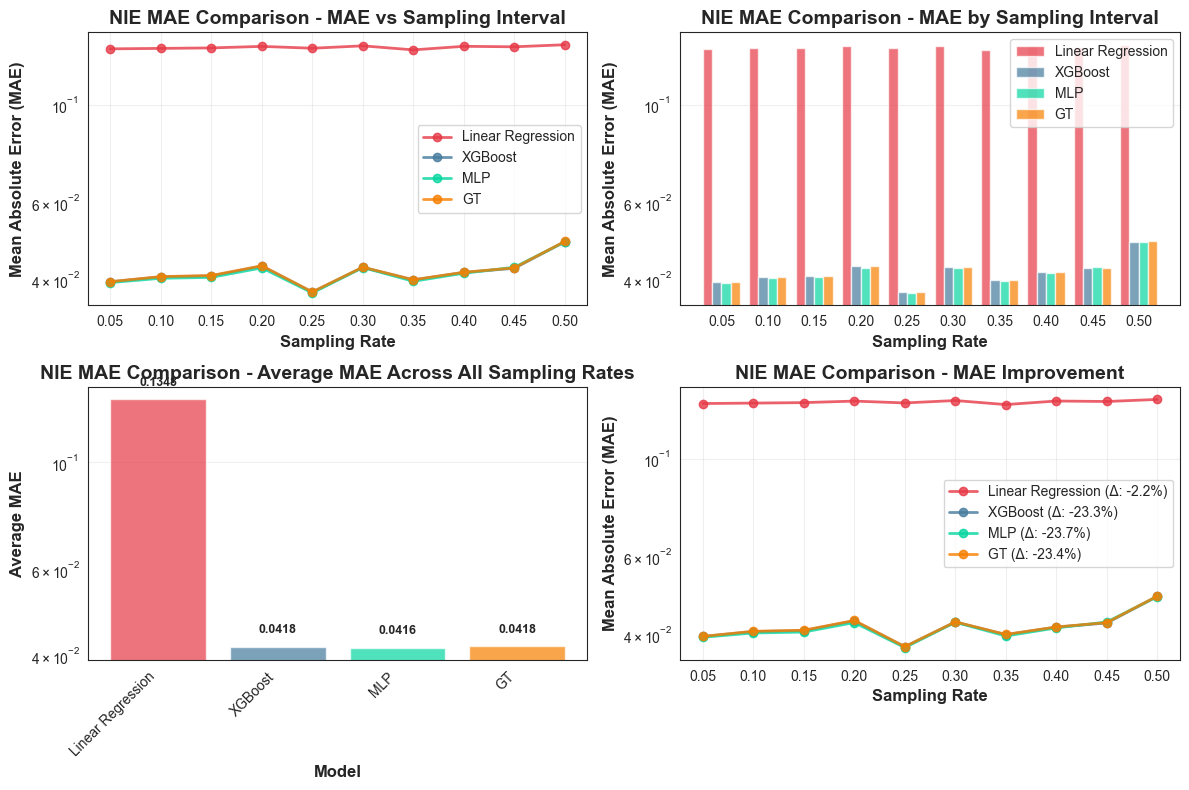


NIE MAE Comparison - Summary Statistics:
Model                Avg MAE      Min MAE      Max MAE      Improvement 
--------------------------------------------------------------------------------
Linear Regression    0.1348       0.1330       0.1366       -2.2        %
XGBoost              0.0418       0.0376       0.0489       -23.3       %
MLP                  0.0416       0.0374       0.0488       -23.7       %
GT                   0.0418       0.0376       0.0489       -23.4       %

Best Model: MLP (Avg MAE: 0.0416)

3. Combined MAE Comparison (All Models and Effects):


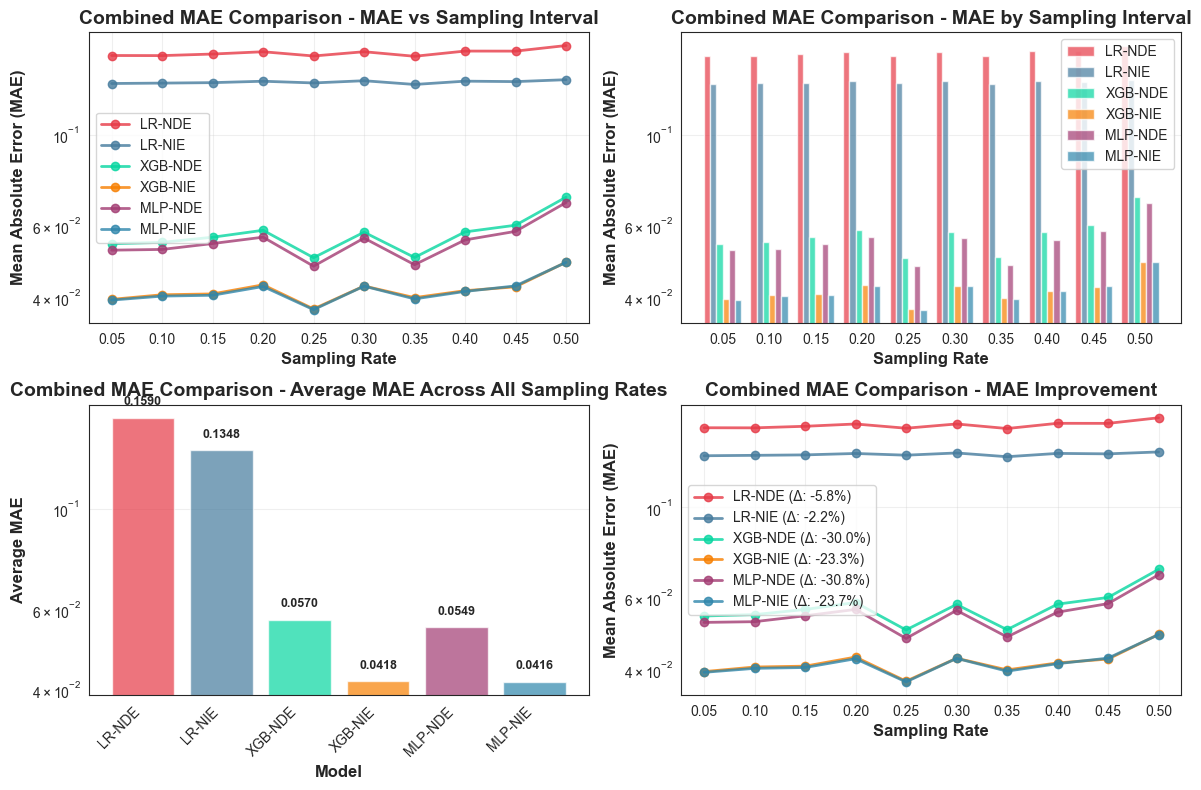


Combined MAE Comparison - Summary Statistics:
Model                Avg MAE      Min MAE      Max MAE      Improvement 
--------------------------------------------------------------------------------
LR-NDE               0.1590       0.1559       0.1656       -5.8        %
LR-NIE               0.1348       0.1330       0.1366       -2.2        %
XGB-NDE              0.0570       0.0501       0.0705       -30.0       %
XGB-NIE              0.0418       0.0376       0.0489       -23.3       %
MLP-NDE              0.0549       0.0478       0.0684       -30.8       %
MLP-NIE              0.0416       0.0374       0.0488       -23.7       %

Best Model: MLP-NIE (Avg MAE: 0.0416)

4. Best Performing Models:
Best NDE Model: MLP
Best NIE Model: MLP
Best Overall Model: MLP-NIE


In [62]:
print("Example: MAE comparison across different models...")

sampling_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


print("\n1. NDE (Natural Direct Effect) Comparison:")
nde_mae_lists = [mae_nde_lr, mae_nde_xgb, mae_nde_mlp, mae_nde_gt]
nde_model_names = ['Linear Regression', 'XGBoost', 'MLP', "GT"]

nde_summary = plot_mae_vs_sampling_rate(
    sampling_rates=sampling_rates,
    mae_lists=nde_mae_lists,
    model_names=nde_model_names,
    title="NDE MAE Comparison"
)

print("\n2. NIE (Natural Indirect Effect) Comparison:")
nie_mae_lists = [mae_nie_lr, mae_nie_xgb, mae_nie_mlp, mae_nie_gt]
nie_model_names = ['Linear Regression', 'XGBoost', 'MLP', "GT"]

nie_summary = plot_mae_vs_sampling_rate(
    sampling_rates=sampling_rates,
    mae_lists=nie_mae_lists,
    model_names=nie_model_names,
    title="NIE MAE Comparison"
)

print("\n3. Combined MAE Comparison (All Models and Effects):")
all_mae_lists = [mae_nde_lr, mae_nie_lr, mae_nde_xgb, mae_nie_xgb, mae_nde_mlp, mae_nie_mlp]
all_model_names = ['LR-NDE', 'LR-NIE', 'XGB-NDE', 'XGB-NIE', 'MLP-NDE', 'MLP-NIE']

combined_summary = plot_mae_vs_sampling_rate(
    sampling_rates=sampling_rates,
    mae_lists=all_mae_lists,
    model_names=all_model_names,
    title="Combined MAE Comparison"
)

print(f"\n4. Best Performing Models:")
print(f"Best NDE Model: {min(nde_summary.keys(), key=lambda x: nde_summary[x]['avg_mae'])}")
print(f"Best NIE Model: {min(nie_summary.keys(), key=lambda x: nie_summary[x]['avg_mae'])}")
print(f"Best Overall Model: {min(combined_summary.keys(), key=lambda x: combined_summary[x]['avg_mae'])}")
